insights que apontei da aula:

NOTA: vale 6v, não 5v. como acho q diz no enunciado

Nota q n sei onde colocar: todo o pre-processing(?) (clustering e cenas) deve ser feito no teste
Nota2: estamos a falar sobre fazer EDA nos dados de treino apenas ou nos dados todos que temos. A prof diz que podemos fazer nos dados todos exatamente para perceber se podemos ter “problemas de valores/categorias/sla n estarem incluídos nos dados de teste”

Target: stress level, valor contínuo de 0 a 10 bastante desbalanceado, podia ser tratado como uma regressão mas é pedido 3 sistemas de classificação:
	 - Binario: stress ou n stress
	- Com 5 classes
	- Com 10 classes, desde n haver nenhum até haver “máximo”
Obj: tentar perceber padroes, nomeadamente tempo tela, café, qnt dorme, atividades, para tentar ver se há relação com o padrão de stress. O “objetivo” prático em si é arbitrário a cada pessoa,  por ex:
- add um “quiz” semanal com tempo de tela (como os teles já fazem) + 2/3 perguntas e assim “avaliar” possível stress
- implementar numa clínica que avalie o stress e com base nisso ofereça produtos/serviços (tipo vc tá mto stressado venha receber uma massagem nossa)

Cada um de nós deve decidir o critério de classificação (pode ser salomónica, p.ex., com 5 classes, 0-2=0, 2-4=1, etc OU fazer clustering para perceber o q se tá a pssar OU focar-se no 9, que é onde está maioria, e dividir o 9 em classes)

Importar -> Analisar (n esquecer na análise reportar o que encontrámos) [inclui pre-processing, encoding, normalização: isto vale no máx 25%, o foco da avaliação é nos modelos, análise e conclusões]

Em termos das experiências, para termos um baseline (perceber o quao dificil é o problema) podemos usar as cenas “básicas”, KNN, NN, Naive Bayes, etc. Esse baseline deve ser por p.ex. uma tabela.
A partir daí, nós temos um modelo que não é determinístico (ñ funciona sempre da mesma maneira: cada vez que pedimos para ele “aprender”, ele aprende de maneira diferente; nas NN, a parte probabilistica é os pesos. Onde nós começamos, tal como no trepa-colina, define o ponto de chegada tbm. isso no código é definido no random state do modelo, o training split deve ser sempre o mesmo (acho q foi isso q a prof disse?) ou seja a 1ª coisa deve ser separar teste e deixá-lo “quietinho”; 30 é um bom nº de redes neuronais). Imaginemos p.ex. que (?n ouvi bem) 30%(?) e desvio padrão de 10 pontos(?):
- 1 hipótese é usar a melhor das redes: Uma coisa que temos que começar a pensar é como que se guarda modelos (a prof disse q p.ex. pode ser em pickles ou sla). Uma rede é os seus pesos;
- outra hipótese é usar as 30 redes e juntá-las para definir nivel stress da pessoa: isto pode ser vantajoso pq o melhor modelo pode ser o ótimo no geral mas pode n ser ótimo para aquele caso. Vantajoso quando p.ex. há nuances que são “overbooked” (palavra de um aluno) pelos modelos

Neste trabalho vamos começar a ter mtos parametros. A nossa rede pode n ser instantanea. Por isso, temos que escolher os hiper parametros, em vez de usar random search ou “research força bruta” (?), devemos usar algo + inteligente como o OPTUNA, que fucniona de forma semelhante, mas dentro do (proprio modelo?) usa gradiente descendente/ascendente

É importante que no relatório coloquemos todas as experiencias que fizemos (e o pq de as termos feito?). É importante que tenahmos o track of evolution e ...? , o OPTUNA faz isso. A prof tá à espera de algo tipo um gráfico com y=F1 e x=nºneuronios ou x=C p.ex., e tenhamos uma parabola e a interpretemos
Segundo a prof: houve launos que usaram o grid search, deu o melhor tipo 90% e nem se deram ao trabalho de ir ver na grid search quais eram os parametros.

Temos de usar 3 ML métodos:
	- SVM
	- NN
	- 3º método, qlq um, exceto os que já demos antes (KNN, decision trees)

A prof disse que páginas de texto devem ser tipo no máximo 10 e figuras/tabelas etc n contam
O código python deve “ser o mais parecido possível com as aulas” (acho q foi isso?). Tivemos uma conversa ampla sobre chat gpt e cenas enfim

O relatório tem que ser feito de forma a que uma pessoa de fora leia e consiga repetir exatamente o que foi feito
O dataset é público, pode haver pessoas que já usaram, houve colegas (a prof achou fixe) que encontraram artigos (n tinham codigo), seguiram as abordagens e melhoraram
A prof diz que a avaliação pdoe ser algo do tipo: 25% pré-modelos, 50% modelos, 25% discussão (conclusao/discussão pode estar misturado com os modelos)



a prof falou sobre a possibilidade de usar naive bayes no problema binário como "eda" (n conta como abordagem)

a prof falou sobre usar rock curve (acho que é isso, gráfico onde y é TP e x é FP; o optuna desenha esse gráfico) e talvez preferir essa métrica do que as métricas normais (accuracy e tal), pq por exemplo em diferentes contextos pode importar mais diferentes métricas. a prof deu o exemplo de detação de fraudes dos bancos, eles preferem accuracy alta e recall a tipo 40% do que recall alto e talvez accuracy mais baixa, pq perdem mais em processos por terem impedido uma pessoa normal de ter pago com o cartão. preferem ent correr um maior risco de deixar passar algumas fraudes desde que quando acusam de fraude, seja MESMO fraude (algo assim)

# 0.

Cada linha do dataset corresponde a um indivíduo. As seguintes variáveis são usadas:
#### 1. Informações
Variáveis que contêm as informações fundamentais de tudo o que envolve essa partida/esse jogo em si.
| Variável | Descrição | Range ou NºValores Únicos |
|:---|:---|:---|
| **`user_id`** | Unique identifier assigned to each individual in the dataset | 15.000 |
| **`age`** | Age of the individual in years | 18-59 |
| **`gender`** | Gender of the individual: **Male**, **Female** ou **Other** | 3 |
| **`occupation`** | Occupation or professional background of the individual: **Manager**, **Doctor**, **Software Engineer**, **Freelancer**, **Student**, **Researcher**, **Designer** ou **Teacher** | 8 |
| **`daily_screen_time_hours`** | Total number of hours spent using digital devices or smartphones per day | 1.0 - 10.0 |
| **`phone_usage_before_sleep_minutes`** | Number of minutes spent using a smartphone before going to sleep | 0.0 - 119.0 |
| **`sleep_duration_hours`** | Total hours of sleep the individual gets per night | 4.0 - 9.0 |
| **`sleep_quality_score`** | A score representing sleep quality, typically ranging from 1 (poor) to 10 (excellent) | 1.0 - 10.0 |
| **`stress_level`** | Measured stress level of the individual on a scale from 1 (low stress) to 10 (high stress): **target!** | 1.0 - 10.0 |
| **`caffeine_intake_cups`** | Number of caffeinated beverages consumed per day | 0.0 - 4.0 |
| **`physical_activity_minutes`** | Total minutes spent on physical activity or exercise per day | 0.0 - 119.0 |
| **`notifications_received_per_day`** | Total number of smartphone notifications received in a day | 20.0 - 299.0 |
| **`mental_fatigue_score`** | A score representing mental fatigue levels ranging from 1 (low fatigue) to 10 (high fatigue) | 1.0 - 10.0 |


# 1.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


# fetch dataset
df = pd.read_csv("sleep_mobile_stress_dataset_15000.csv")
df.columns


Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='object')

In [3]:
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [4]:
df.shape

(15000, 13)

In [5]:
df.isnull().sum()
#Sem valores nulos

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [6]:
df.duplicated().sum()
#Sem valores duplicados

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

In [8]:
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [9]:
df.describe(include="object")
#
#top: Categoria que ocorre com maior frequência
#freq: Número de observações do top

,gender,occupation
count,15000,15000
unique,3,8
top,Male,Manager
freq,7234,1962


In [10]:
df['gender'].value_counts()

gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64

In [11]:
df['occupation'].value_counts()

occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64

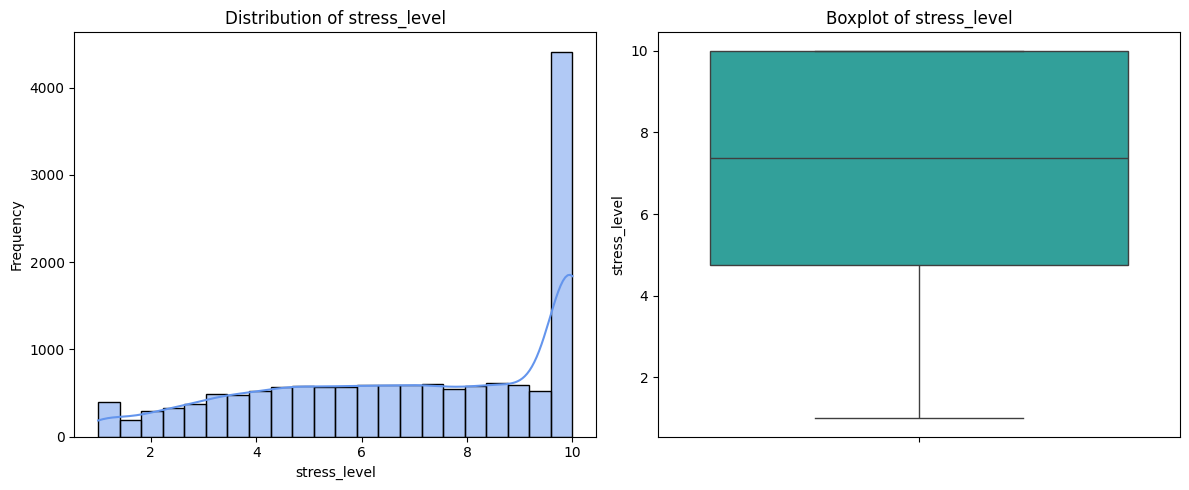

In [12]:
#Before building the model, it is important to understand the target variable that the model will predict.
def plot_distribution(data, column):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.histplot(data[column], kde=True, color="cornflowerblue")
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.subplot(1,2,2)
    sns.boxplot(y=data[column], color="lightseagreen")
    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

    
plot_distribution(df, "stress_level")


In [13]:
# arredondar cada stress_level para o inteiro mais próximo e depois imprimir as percentagens de cada categoria
df['stress_level_rounded'] = df['stress_level'].round().astype(int)
stress_level_counts = df['stress_level_rounded'].value_counts(normalize=True) * 100
print(stress_level_counts)

# imprimir % [0, 5[ e % [5, 10]
stress_level_0_5 = df[(df['stress_level'] >= 0) & (df['stress_level'] < 5)].shape[0] / df.shape[0] * 100
stress_level_5_10 = df[(df['stress_level'] >= 5) & (df['stress_level'] <= 10)].shape[0] / df.shape[0] * 100
print(f"Percentage of stress_level in [0, 5[: {stress_level_0_5:.2f}%")
print(f"Percentage of stress_level in [5, 10]: {stress_level_5_10:.2f}%\n")

# imprimir % [0, 9[ e % [9, 10]
stress_level_0_8 = df[(df['stress_level'] >= 0) & (df['stress_level'] < 9)].shape[0] / df.shape[0] * 100
stress_level_8_10 = df[(df['stress_level'] >= 9) & (df['stress_level'] <= 10)].shape[0] / df.shape[0] * 100
print(f"Percentage of stress_level in [0, 9[: {stress_level_0_8:.2f}%")
print(f"Percentage of stress_level in [9, 10]: {stress_level_8_10:.2f}%\n")

stress_level_rounded
10    30.186667
7      9.740000
5      9.440000
6      9.406667
9      9.406667
8      9.326667
4      8.353333
3      6.820000
2      4.400000
1      2.920000
Name: proportion, dtype: float64
Percentage of stress_level in [0, 5[: 27.37%
Percentage of stress_level in [5, 10]: 72.63%

Percentage of stress_level in [0, 9[: 65.28%
Percentage of stress_level in [9, 10]: 34.72%



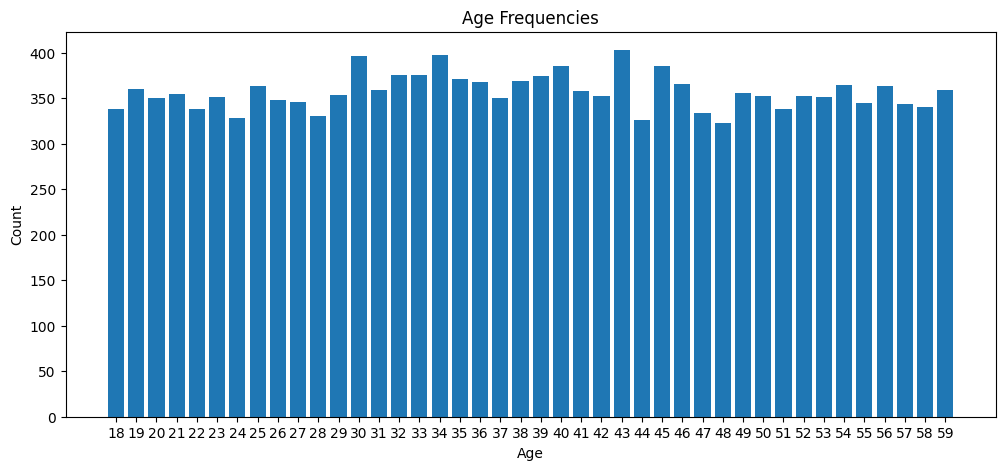

In [37]:
counts = df["age"].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.bar(counts.index, counts.values)

plt.title("Age Frequencies")
plt.xlabel("Age")
plt.ylabel("Count")

plt.xticks(counts.index)

plt.show()

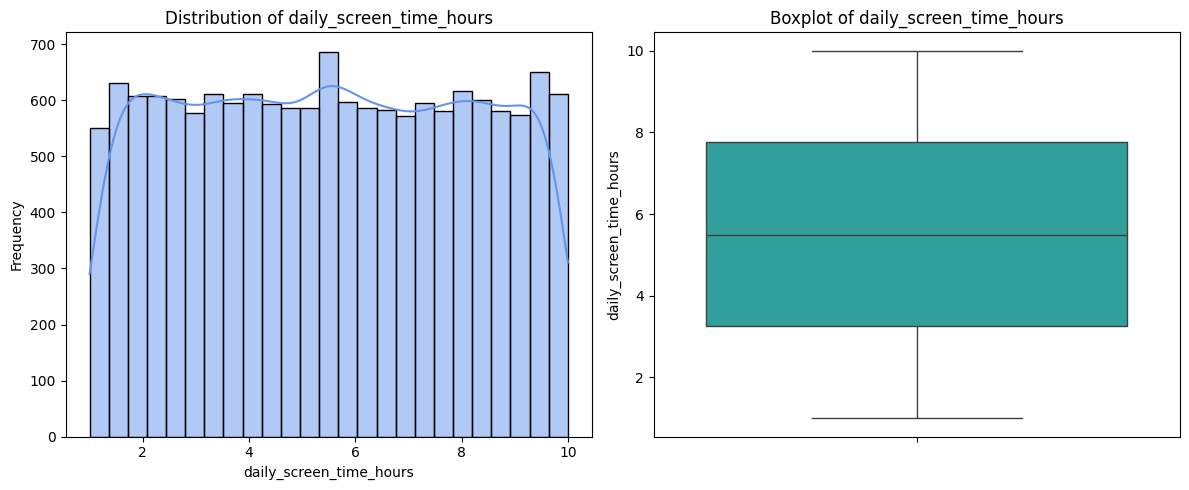

In [16]:
plot_distribution(df, "daily_screen_time_hours")

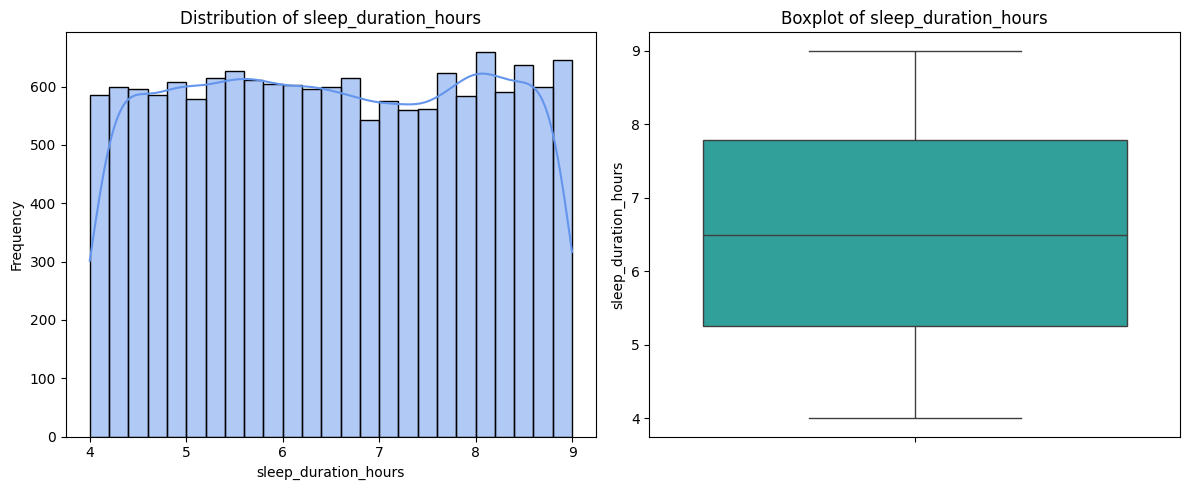

In [17]:
plot_distribution(df, "sleep_duration_hours")

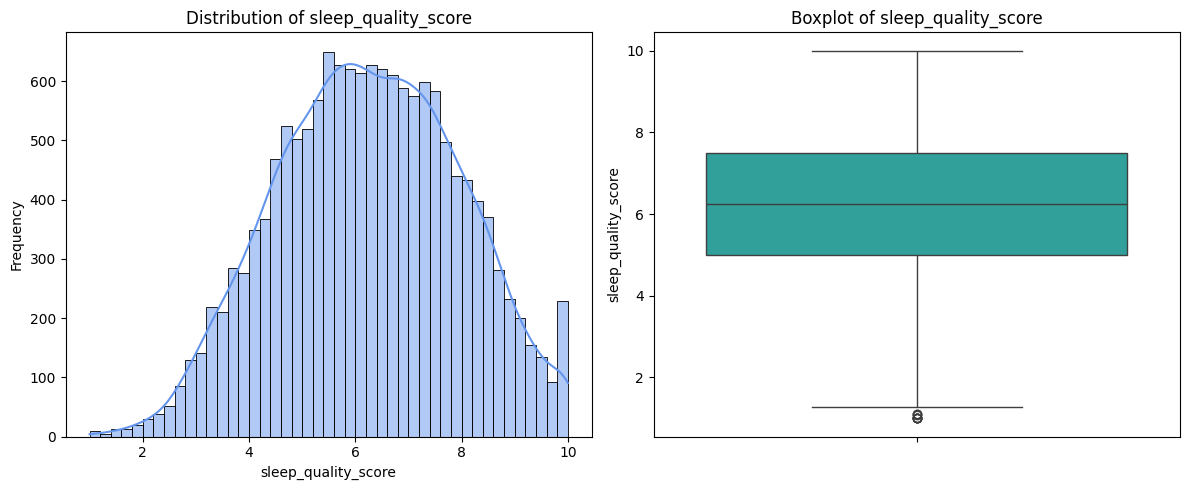

In [18]:
plot_distribution(df, "sleep_quality_score")

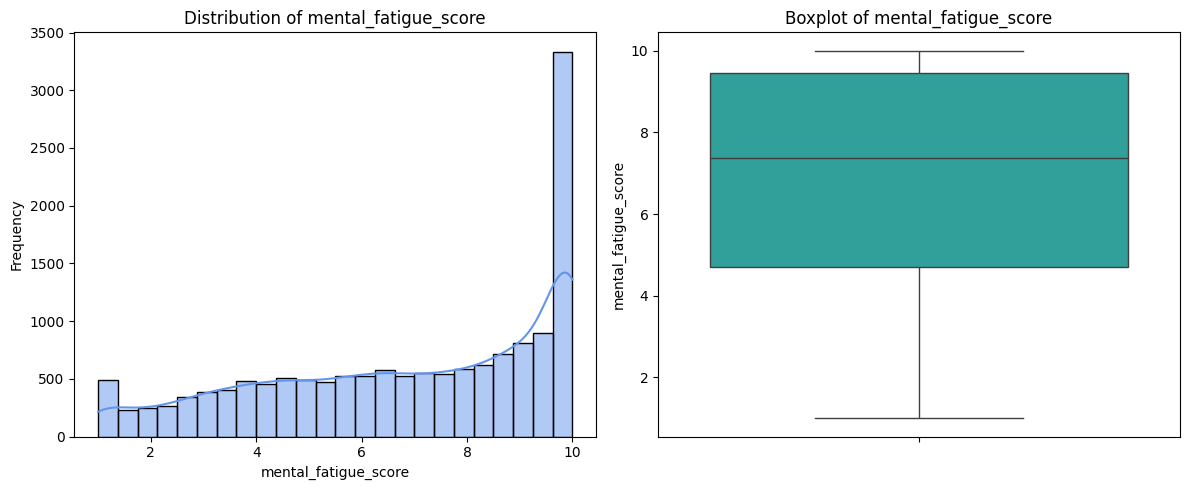

In [19]:
plot_distribution(df, "mental_fatigue_score")

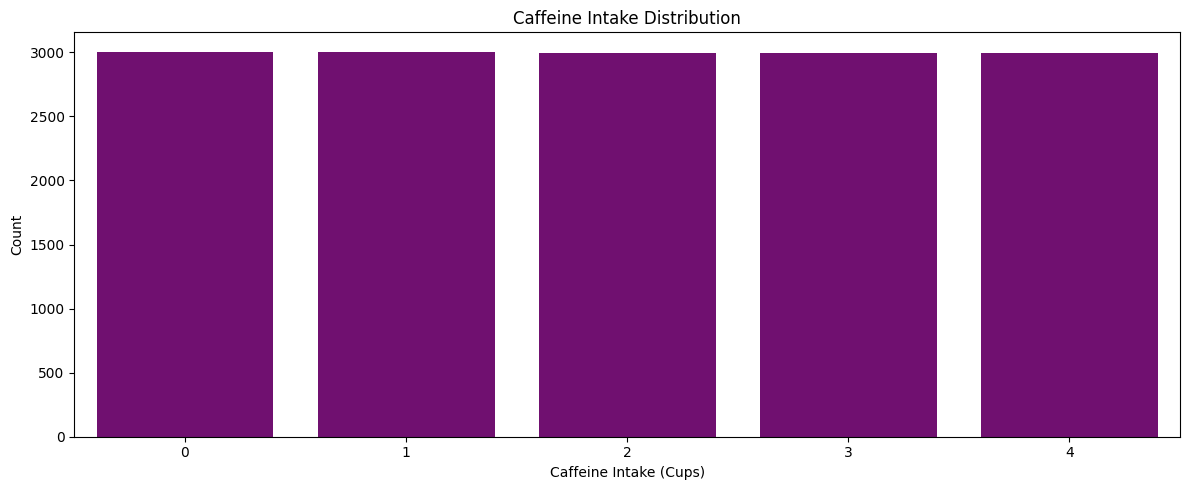

In [20]:
plt.figure(figsize=(12,5))

sns.countplot(x=df["caffeine_intake_cups"], color="purple")
plt.title("Caffeine Intake Distribution")
plt.xlabel("Caffeine Intake (Cups)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

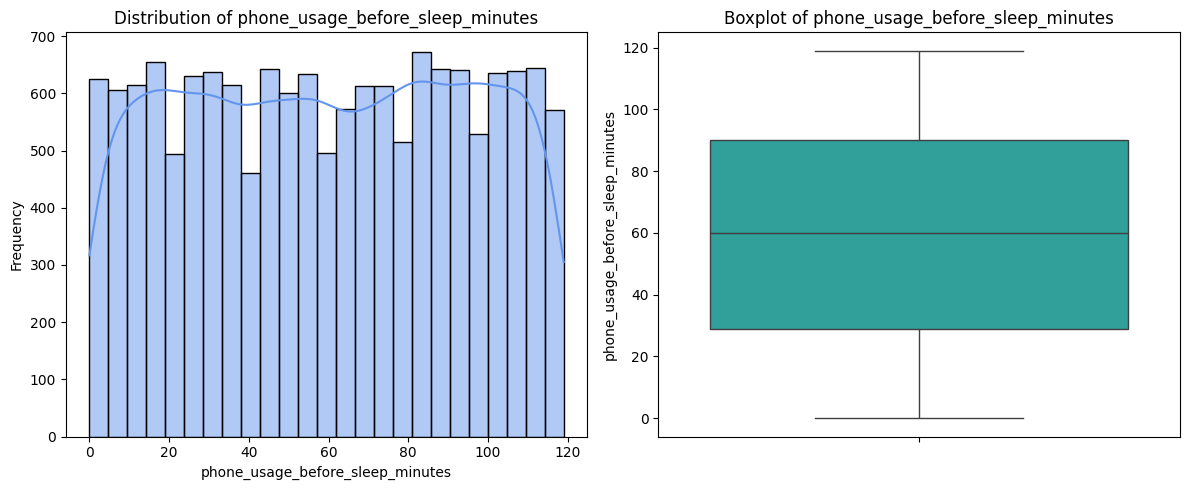

In [39]:
plot_distribution(df, "phone_usage_before_sleep_minutes")

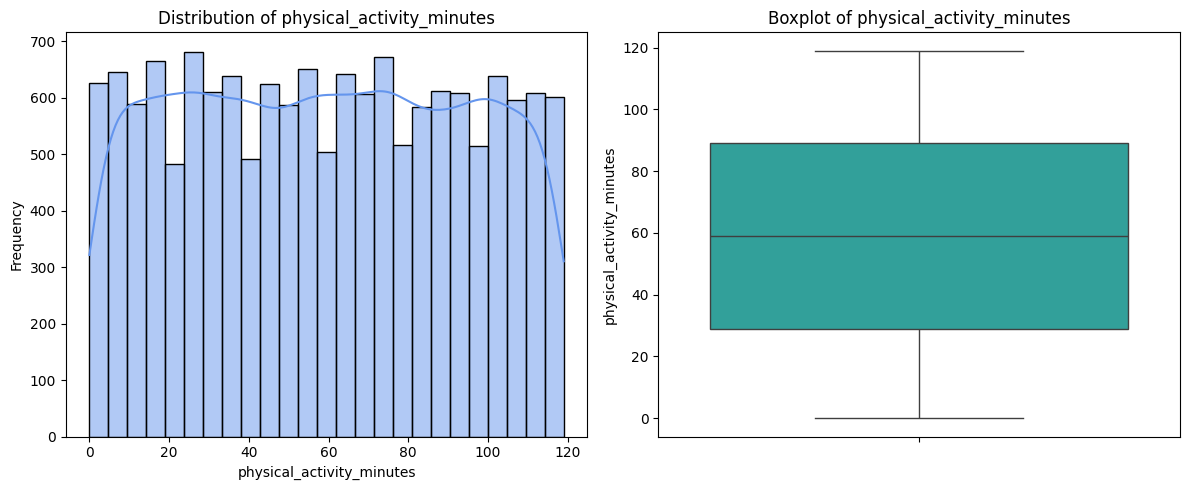

In [40]:
plot_distribution(df, "physical_activity_minutes")

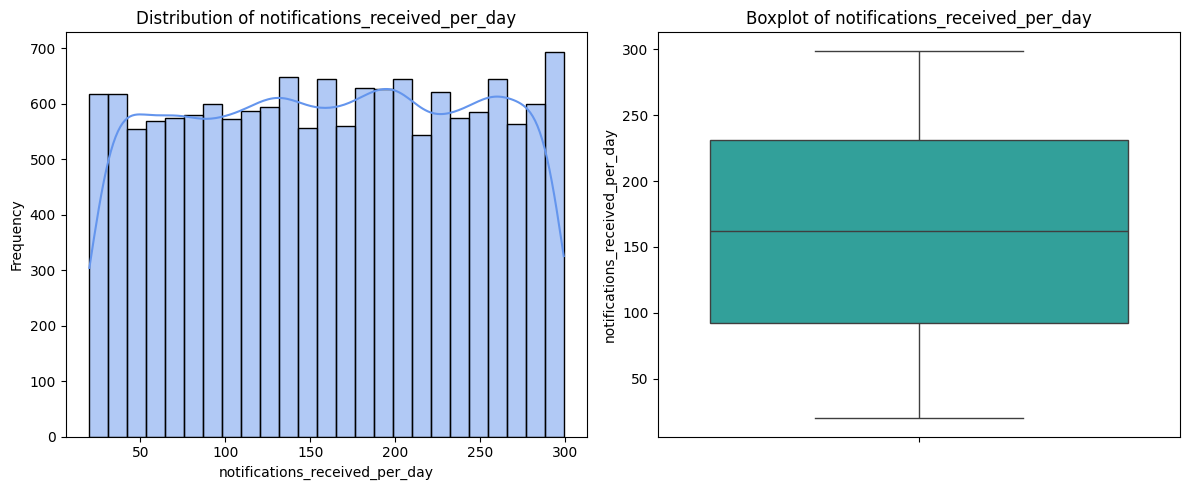

In [41]:
plot_distribution(df, "notifications_received_per_day")

In [21]:
# Numerical Variables Analysis:

# The distributions of the numerical variables provide useful insights into the structure of the dataset.

# The age variable appears to be relatively evenly distributed between approximately 18 and 59 years, suggesting that the dataset includes a balanced representation of young and middle-aged individuals.

# The daily screen time variable ranges between roughly 1 and 10 hours, with a median around 5–6 hours. This indicates moderate screen usage among most individuals in the dataset.

# The sleep duration variable ranges from about 4 to 9 hours, with most observations concentrated between 5 and 8 hours, which aligns with typical sleep patterns.

# The physical activity variable shows a wide distribution between 0 and 120 minutes, suggesting that the dataset includes individuals with very different activity levels.

# The sleep quality score appears to follow a roughly normal distribution centered around the middle range, indicating moderate sleep quality for most individuals.

# Similarly, mental fatigue scores tend to concentrate in the higher range, suggesting that many individuals in the dataset experience moderate to high levels of mental fatigue.

# Finally, the caffeine intake distribution shows discrete levels between 0 and 4 cups, with a relatively balanced frequency across categories.

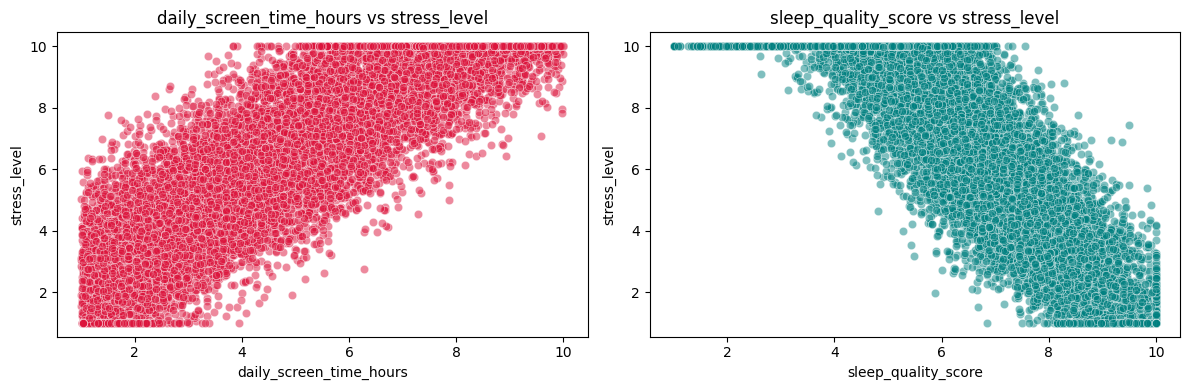

In [22]:
#Relationships with Stress Level
#The analysis focuses on daily screen time, sleep duration, sleep quality, and phone usage before sleep to examine how these factors may be associated with stress levels.
def plot_scatter_pair(df, x1, x2, y="stress_level"):

    plt.figure(figsize=(12,4))

    # Grafik 1
    plt.subplot(1,2,1)
    sns.scatterplot(x=x1, y=y, data=df,   color="crimson", alpha=0.5)
    plt.title(f"{x1} vs {y}")
    plt.xlabel(x1)
    plt.ylabel(y)

    # Grafik 2
    plt.subplot(1,2,2)
    sns.scatterplot(x=x2, y=y, data=df, alpha=0.5,  color="teal",)
    plt.title(f"{x2} vs {y}")
    plt.xlabel(x2)
    plt.ylabel(y)

    plt.tight_layout()
    plt.show()

plot_scatter_pair(df, "daily_screen_time_hours", "sleep_quality_score")
#The scatter plots reveal clear relationships between lifestyle factors and stress levels.

# A positive relationship can be observed between daily screen time and stress level. As screen time increases, stress levels tend to increase as well. Individuals with higher screen usage (around 7–10 hours) generally show higher stress values compared to those with lower screen time.

# In contrast, sleep quality shows a strong negative relationship with stress level. Higher sleep quality scores are associated with lower stress levels, while individuals with lower sleep quality tend to experience higher stress.



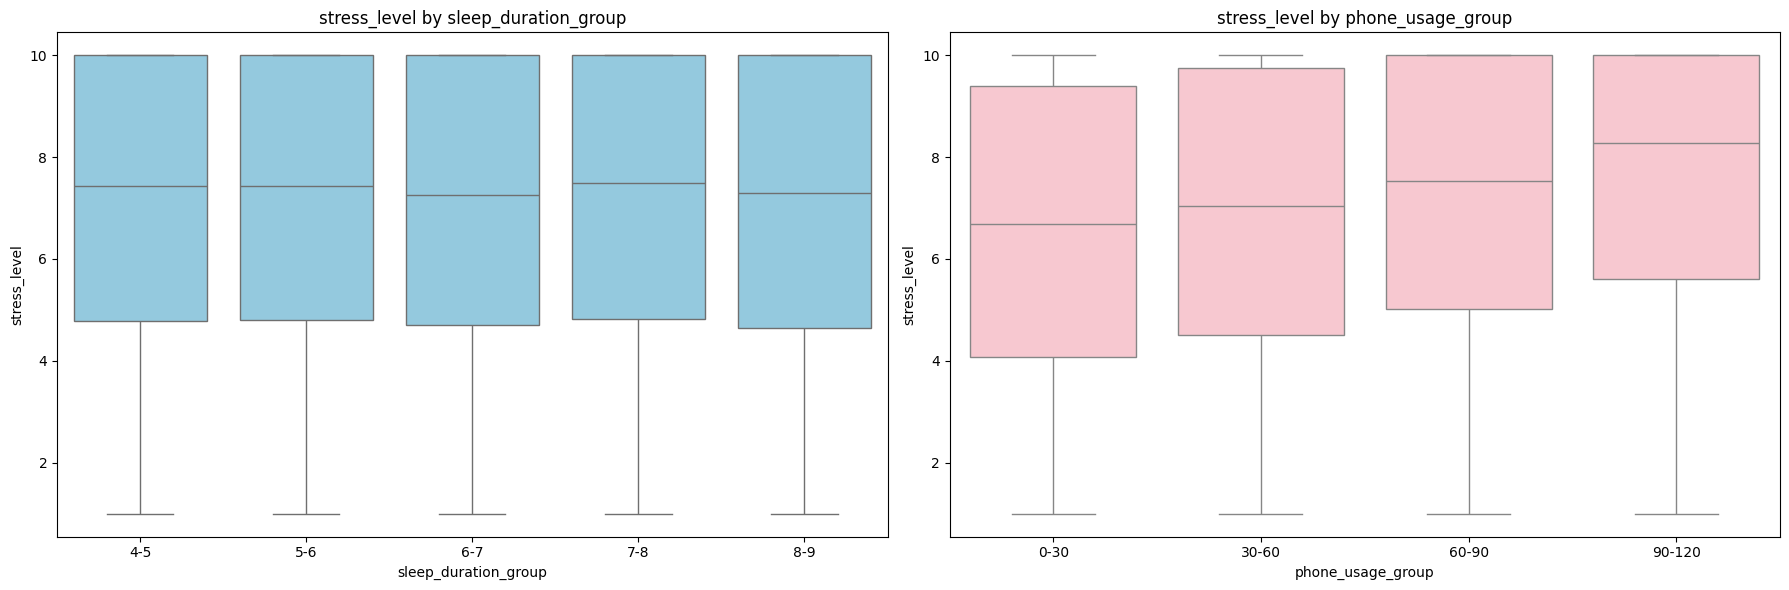

In [23]:
def plot_box_pair(df, x1, x2, y="stress_level"):

    plt.figure(figsize=(18,6))

    # Grafik 1
    plt.subplot(1,2,1)
    sns.boxplot(x=x1, y=y, data=df, color="skyblue")
    plt.title(f"{y} by {x1}")
    plt.xlabel(x1)
    plt.ylabel(y)

    # Grafik 2
    plt.subplot(1,2,2)
    sns.boxplot(x=x2, y=y, data=df, color="pink")
    plt.title(f"{y} by {x2}")
    plt.xlabel(x2)
    plt.ylabel(y)

    plt.tight_layout()
    plt.show()

df["sleep_duration_group"] = pd.cut(
    df["sleep_duration_hours"],
    bins=[4,5,6,7,8,9],
    labels=["4-5","5-6","6-7","7-8","8-9"]
)
df["phone_usage_group"] = pd.cut(
    df["phone_usage_before_sleep_minutes"],
    bins=[0,30,60,90,120],
    labels=["0-30","30-60","60-90","90-120"]
)
plot_box_pair(df, "sleep_duration_group", "phone_usage_group")
#The boxplots provide insights into how stress levels vary across different sleep duration and phone usage groups.

# The results indicate that sleep duration alone does not show a strong variation in stress levels, as the distributions appear relatively similar across different sleep duration categories. This suggests that sleep duration by itself may not be a strong predictor of stress.

# In contrast, phone usage before sleep shows a clearer pattern. As phone usage duration increases, stress levels tend to increase as well. Individuals who use their phones for longer periods before sleep generally exhibit higher stress levels compared to those with shorter usage times.

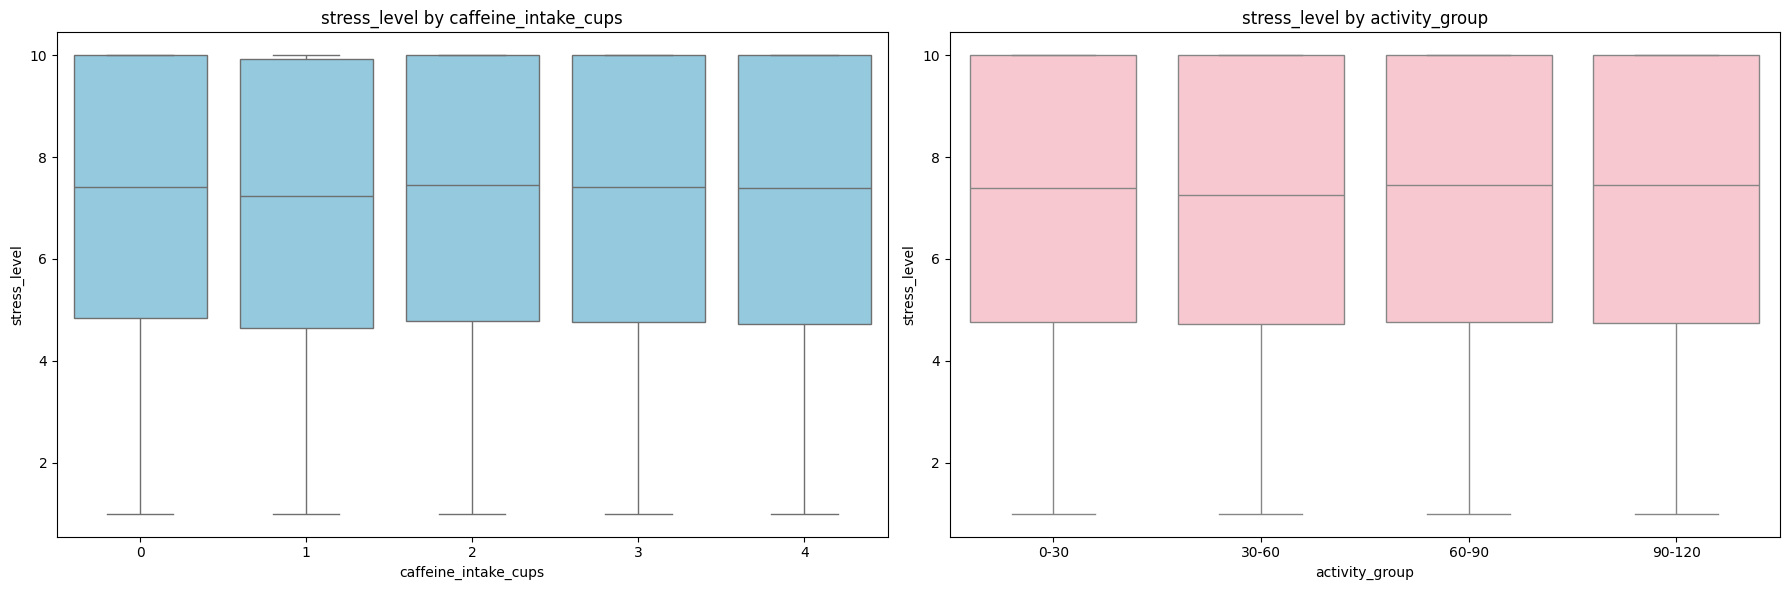

In [24]:
# Lifestyle Factors
# In this section, the relationship between stress levels and lifestyle-related variables is explored. The analysis focuses on caffeine consumption, physical activity, daily notifications, and mental fatigue to evaluate how these factors may be associated with stress levels.

df["activity_group"] = pd.cut(
    df["physical_activity_minutes"],
    bins=[0,30,60,90,120],
    labels=["0-30","30-60","60-90","90-120"]
)
plot_box_pair(df, "caffeine_intake_cups", "activity_group")


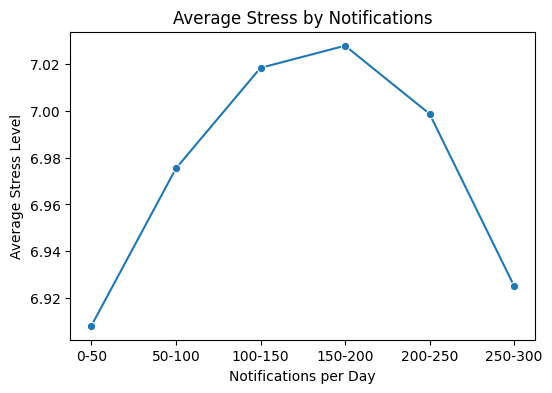

In [25]:
df["notification_group"] = pd.cut(
    df["notifications_received_per_day"],
    bins=[0,50,100,150,200,250,300],
    labels=["0-50","50-100","100-150","150-200","200-250","250-300"]
)
notification_mean = (
    df.groupby("notification_group", observed=True)["stress_level"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(6,4))

sns.lineplot(
    x="notification_group",
    y="stress_level",
    data=notification_mean,
    marker="o"
)

plt.title("Average Stress by Notifications")
plt.xlabel("Notifications per Day")
plt.ylabel("Average Stress Level")

plt.show()

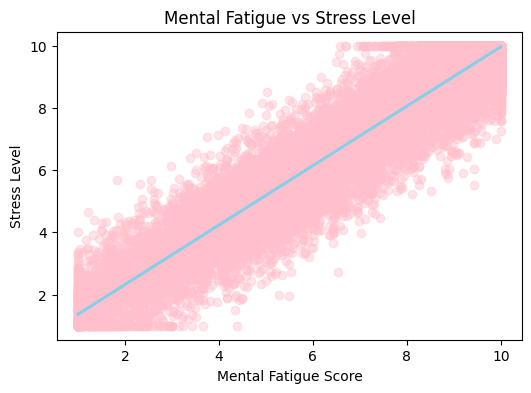

In [26]:
plt.figure(figsize=(6,4))

sns.regplot(
    x="mental_fatigue_score",
    y="stress_level",
    data=df,
    color = "pink",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"skyblue"}
)

plt.title("Mental Fatigue vs Stress Level")
plt.xlabel("Mental Fatigue Score")
plt.ylabel("Stress Level")

plt.show()
# The boxplots for caffeine intake show that stress levels are relatively similar across different caffeine consumption groups. This suggests that caffeine intake alone may not have a strong direct effect on stress levels in this dataset.

# Similarly, physical activity groups display comparable stress distributions. Although physical activity is generally associated with better well-being, the differences between activity levels in this dataset appear limited.

# The notifications analysis indicates a slight increase in average stress levels as the number of daily notifications rises, suggesting that frequent digital interruptions may contribute to higher stress.

# Finally, the scatter plot between mental fatigue and stress level reveals a strong positive relationship. As mental fatigue increases, stress levels increase significantly. This indicates that mental fatigue is likely one of the most influential factors associated with stress in this dataset.

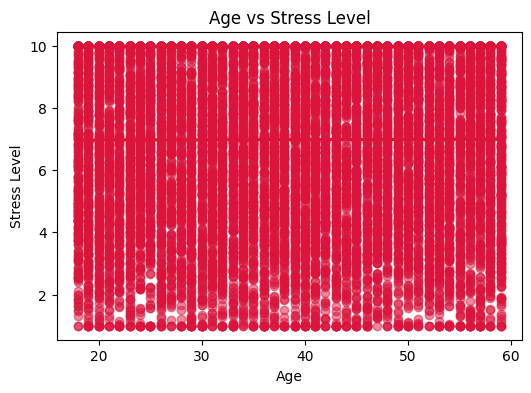

In [27]:
# Demographic Comparisons
# In this section, stress levels are analyzed across different demographic groups.
# The analysis focuses on whether stress levels vary according to age, gender, and occupation.

plt.figure(figsize=(6,4))

sns.regplot(
    x="age",
    y="stress_level",
    data=df,
    scatter_kws={"alpha":0.5},
    color ="crimson"
)

plt.title("Age vs Stress Level")
plt.xlabel("Age")
plt.ylabel("Stress Level")

plt.show()

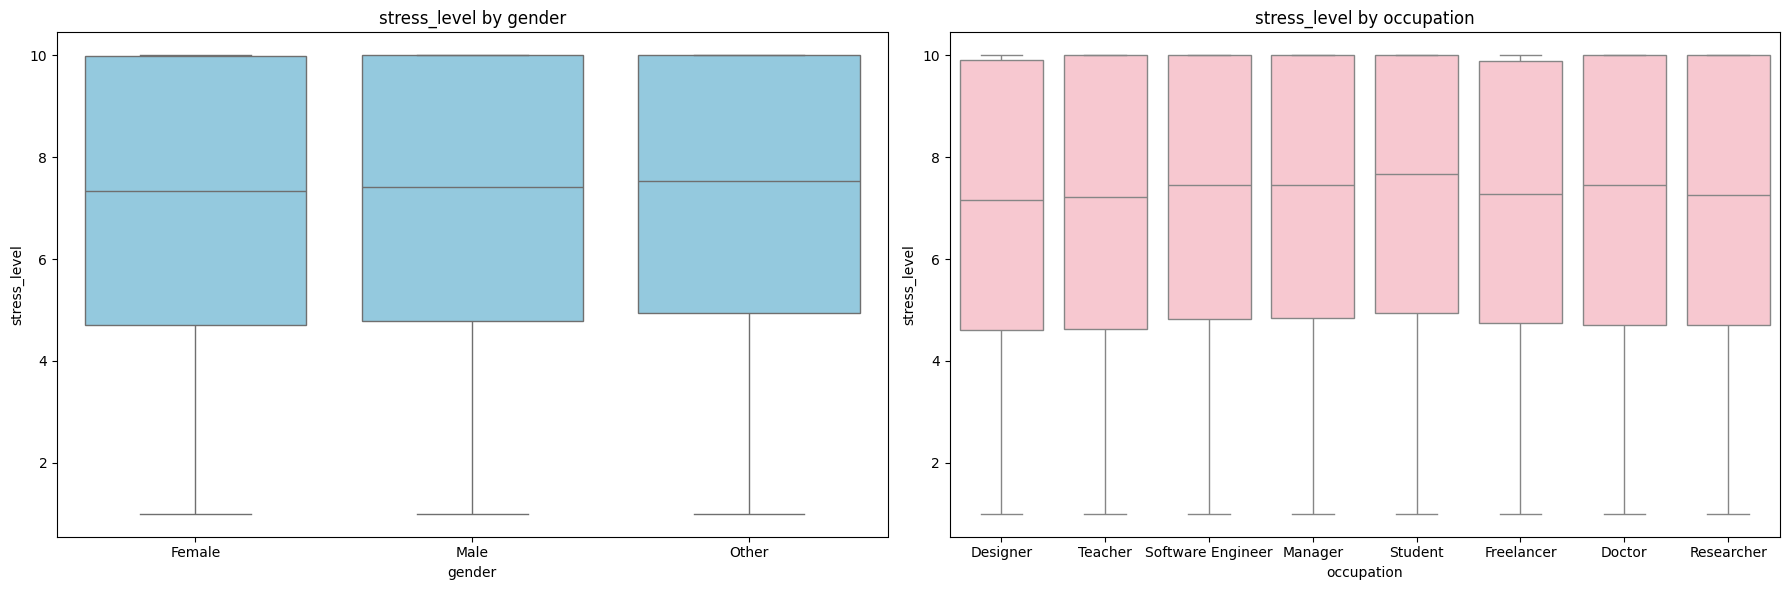

In [28]:
plot_box_pair(df, "gender", "occupation")
# The scatter plot between age and stress level does not reveal a clear relationship. Stress values appear widely distributed across all age groups, suggesting that age alone may not be a strong predictor of stress in this dataset.

# The gender comparison shows that stress distributions are quite similar across different gender categories. The median stress levels and variability appear comparable, indicating that gender does not create a strong separation in stress levels.

# Similarly, the occupation-based analysis shows relatively similar stress distributions across different professions. While minor differences exist between occupations, no single profession stands out as having significantly higher or lower stress levels.

# Overall, demographic variables such as age, gender, and occupation appear to have a limited direct influence on stress levels compared to lifestyle-related factors observed earlier in the analysis.


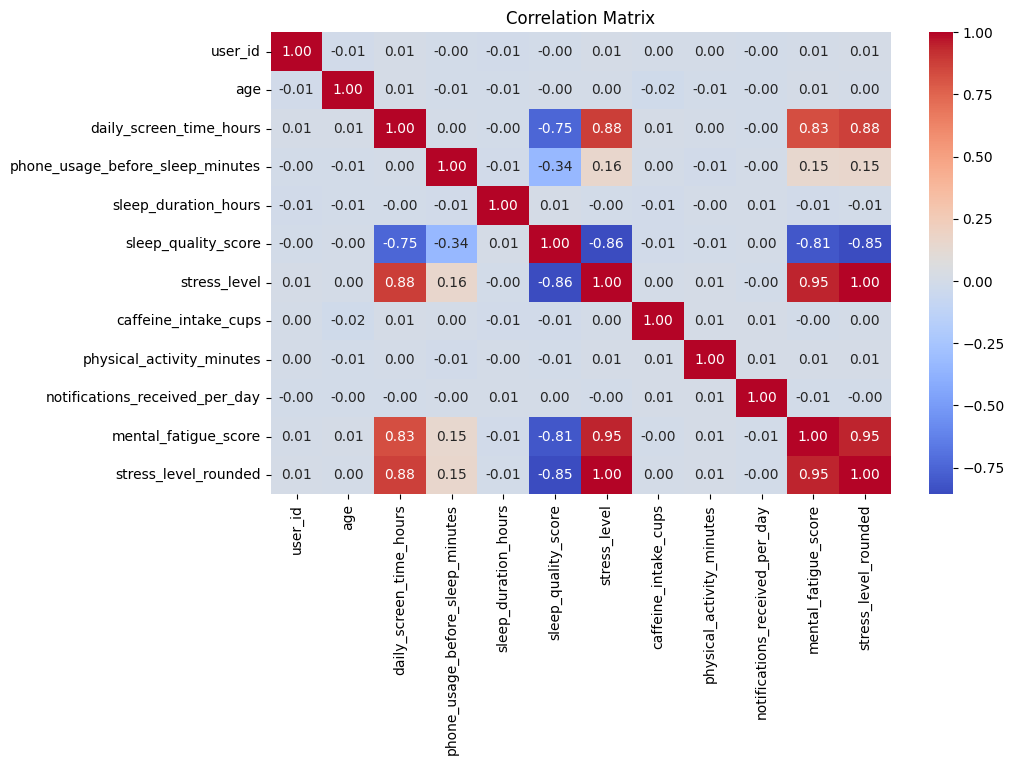

In [29]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [30]:
# The exploratory analysis reveals several important patterns related to stress levels.

# Mental fatigue shows the strongest relationship with stress, indicating that psychological exhaustion plays a critical role in determining stress levels.
# Daily screen time also displays a strong positive association with stress, suggesting that extended digital exposure may contribute to increased stress.

# Sleep quality appears to be strongly negatively correlated with stress, meaning that individuals with better sleep quality tend to experience lower stress levels.
# Additionally, higher screen time and mental fatigue are associated with lower sleep quality.

# Lifestyle variables such as caffeine intake and physical activity show relatively weak relationships with stress, while demographic variables including age, gender, and occupation appear to have minimal direct influence.

# Overall, the analysis suggests that behavioral and lifestyle factors, particularly mental fatigue, screen time, and sleep quality, are the most important variables associated with stress levels in this dataset.